In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('ccc_clean.csv')

In [3]:
df.shape

(113807, 31)

# predicting salary

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113807 entries, 0 to 113806
Data columns (total 31 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   index                         113807 non-null  int64  
 1   job_id                        113807 non-null  object 
 2   company_name                  113807 non-null  object 
 3   company_type                  113807 non-null  object 
 4   sector                        113564 non-null  object 
 5   company_size_employees        113807 non-null  int64  
 6   hq_country                    113807 non-null  object 
 7   job_role                      113564 non-null  object 
 8   seniority_level               113807 non-null  object 
 9   years_experience_min          113807 non-null  int64  
 10  years_experience_max          113807 non-null  int64  
 11  required_tech_stack           113807 non-null  object 
 12  primary_programming_language  90529 non-null

In [5]:
df['layoff_within_12_months_flag'].value_counts()

layoff_within_12_months_flag
0.0    98676
1.0    14888
Name: count, dtype: int64

In [6]:
df['layoff_within_12_months_flag'].notnull().value_counts()

layoff_within_12_months_flag
True     113564
False       243
Name: count, dtype: int64

In [7]:
df['salary_mid_usd'].isnull().value_counts()

salary_mid_usd
False    108203
True       5604
Name: count, dtype: int64

In [8]:
df['salary_mid_usd'].describe()

count    1.082030e+05
mean     1.287553e+05
std      6.988888e+04
min      0.000000e+00
25%      8.455000e+04
50%      1.171000e+05
75%      1.618500e+05
max      1.910150e+06
Name: salary_mid_usd, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

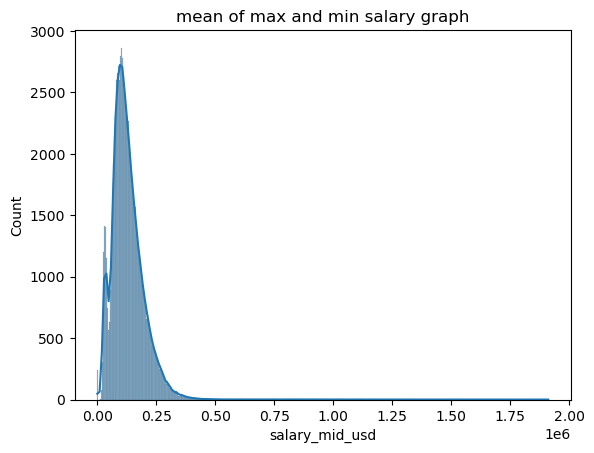

In [9]:
sns.histplot(data=df, x='salary_mid_usd', kde='Ture')
plt.title('mean of max and min salary graph')
plt.show

In [10]:
df['salary_mid_usd'].median()

117100.0

- replacing the missing mid salary values with median as data is highly concentrated median

In [11]:
df['salary_mid_usd']=df['salary_mid_usd'].fillna(df['salary_mid_usd'].median())

In [12]:
df['salary_mid_usd'].isnull().value_counts()

salary_mid_usd
False    113807
Name: count, dtype: int64

In [13]:
df['salary_mid_usd'].describe()

count    1.138070e+05
mean     1.281814e+05
std      6.819308e+04
min      0.000000e+00
25%      8.630000e+04
50%      1.171000e+05
75%      1.589500e+05
max      1.910150e+06
Name: salary_mid_usd, dtype: float64

In [14]:
df['company_size_employees'].isnull().value_counts()

company_size_employees
False    113807
Name: count, dtype: int64

In [15]:
df['company_size_employees'].describe()

count    113807.000000
mean     105163.301519
std      102133.236497
min           0.000000
25%        5987.500000
50%       88023.000000
75%      169638.500000
max      488674.000000
Name: company_size_employees, dtype: float64

In [16]:
df['years_experience_min'].isnull().value_counts()

years_experience_min
False    113807
Name: count, dtype: int64

In [17]:
df['years_experience_min'].describe()

count    113807.000000
mean          2.998234
std           3.092776
min           0.000000
25%           1.000000
50%           2.000000
75%           5.000000
max          24.000000
Name: years_experience_min, dtype: float64

In [18]:
df['years_experience_max'].isnull().value_counts()

years_experience_max
False    113807
Name: count, dtype: int64

In [19]:
df['years_experience_max'].describe()

count    113807.000000
mean          6.650716
std           5.076238
min           0.000000
25%           3.000000
50%           5.000000
75%           9.000000
max          24.000000
Name: years_experience_max, dtype: float64

In [20]:
to_replace=df.loc[df['years_experience_min']>df['years_experience_max']]

In [21]:
to_replace.shape

(313, 31)

In [22]:
to_replace = df['years_experience_min'] > df['years_experience_max']

df.loc[to_replace, ['years_experience_min', 'years_experience_max']] = (df.loc[to_replace, ['years_experience_max', 'years_experience_min']].values)

In [23]:
df['years_experience_min'].describe()

count    113807.000000
mean          2.987154
std           3.076292
min           0.000000
25%           1.000000
50%           2.000000
75%           5.000000
max          13.000000
Name: years_experience_min, dtype: float64

In [24]:
df['years_experience_max'].describe()

count    113807.000000
mean          6.661796
std           5.078257
min           0.000000
25%           3.000000
50%           5.000000
75%           9.000000
max          24.000000
Name: years_experience_max, dtype: float64

### choosing integer columns for features

- company_size_employees
- years_experience_min
- years_experience_max

In [25]:
features = ["company_size_employees","years_experience_min","years_experience_max"]

X=df[features]
y=df['salary_mid_usd']


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 30521.94446045023
MSE : 2458765747.063256
RMSE: 49585.94303896272
R²  : 0.47572183713876603


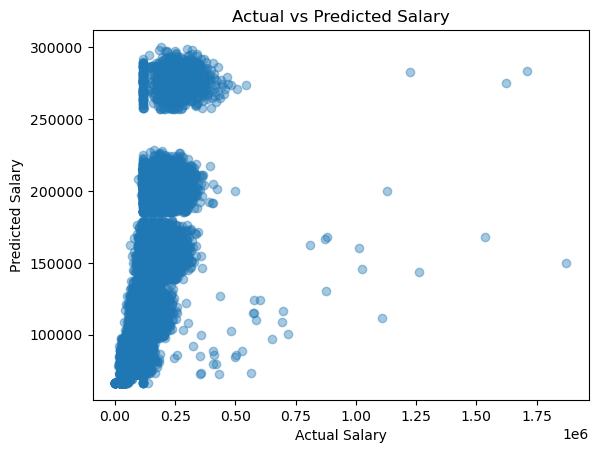

In [30]:

plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

### trying it now by gradient descent

In [31]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

- StandarScaler : changes the scale of numerical features by 

z= x-(mean(x))  /  standard deviation

- make_pipeline: connects transformed features and model together

In [32]:
gd_model= make_pipeline(
    StandardScaler(),
    SGDRegressor(
        loss='squared_error',
        max_iter=1000,
        eta0=0.01,
        random_state=10
    )
)

In [33]:
gd_model.fit(X_train, y_train)
y_pred_gd= gd_model.predict(X_test)

In [34]:

mae = mean_absolute_error(y_test, y_pred_gd)
mse = mean_squared_error(y_test, y_pred_gd)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_gd)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 30599.408646929736
MSE : 2460609018.8809147
RMSE: 49604.52619349281
R²  : 0.47532879963067065


In [35]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.4757


 _accuracy is very low_

_taking more features_

In [36]:
df['salary_min_usd']=df['salary_min_usd'].fillna(df['salary_min_usd'].median())

In [37]:
df['salary_max_usd']=df['salary_max_usd'].fillna(df['salary_max_usd'].median())

- adding max salary and min salary to features

In [38]:
features = ["company_size_employees","years_experience_min","years_experience_max",'salary_max_usd','salary_min_usd']

X=df[features]
y=df['salary_mid_usd']


In [39]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [40]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
y_pred_more = model.predict(X_test)

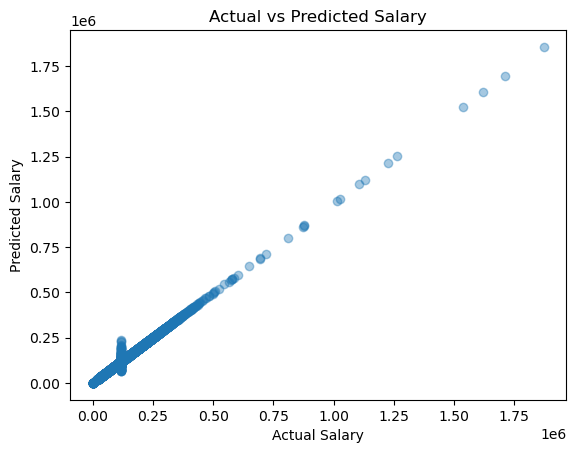

In [42]:
plt.scatter(y_test, y_pred_more, alpha=0.4)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

In [43]:
mae = mean_absolute_error(y_test, y_pred_more)
mse = mean_squared_error(y_test, y_pred_more)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_more)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 457.84774950873356
MSE : 10408147.41794307
RMSE: 3226.1660555438043
R²  : 0.997780689594531


In [44]:
features = ["company_size_employees","years_experience_min","years_experience_max"]

X=df[features]
y=df['salary_mid_usd']

In [45]:
from sklearn.preprocessing import PolynomialFeatures
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)
poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
model.fit(X_train_poly,y_train)
y_pred_poly=model.predict(X_test_poly)

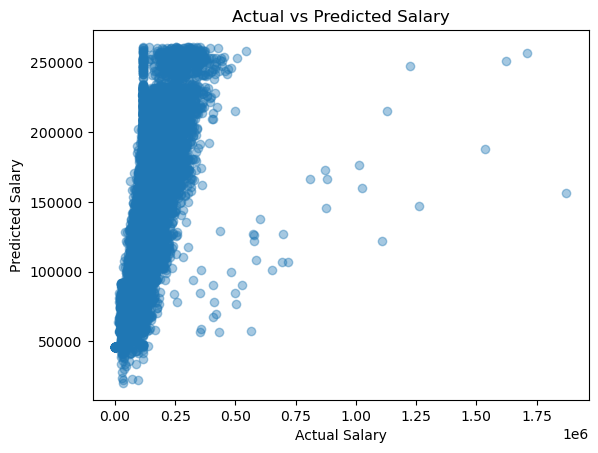

In [46]:
plt.scatter(y_test, y_pred_poly, alpha=0.4)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

In [47]:
mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 29168.917932409957
MSE : 2300068135.479645
RMSE: 47959.025589347046
R²  : 0.5095606411610267


# logistic regression for predicting layoff in 12 months

In [48]:
df['layoff_within_12_months_flag'].isnull().value_counts()

layoff_within_12_months_flag
False    113564
True        243
Name: count, dtype: int64

_removing null_

In [72]:
df = df.dropna(subset=['layoff_within_12_months_flag'])
df['layoff_within_12_months_flag'].value_counts()

layoff_within_12_months_flag
0.0    98676
1.0    14888
Name: count, dtype: int64

- classes already into 1 and 0

- 0 for false and 1 for true

In [73]:
features= ['company_type','sector','company_size_employees','hq_country','offers_extended','offers_accepted']
X=df[features]
y=df['layoff_within_12_months_flag']

In [74]:
X.head()

,company_type,sector,company_size_employees,hq_country,offers_extended,offers_accepted
0,MNC,Healthtech,146085,Germany,5.0,5.0
1,Mid-size,Cloud/Infra,5882,USA,1.0,0.0
2,MNC,Healthtech,186507,USA,1.0,1.0
3,Unicorn,Healthtech,10930,Brazil,6.0,5.0
4,MNC,Social/Adtech,42510,USA,1.0,1.0


- converting categorial features to int

In [75]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [76]:
transformer= ColumnTransformer(
transformers=[
('transform1',SimpleImputer(),['offers_extended','offers_accepted','company_size_employees']),
('transfrom2',OneHotEncoder(sparse_output=False,drop='first'),['company_type','sector','hq_country'])
],remainder='passthrough'
)

In [77]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [78]:
X_train_transform=transformer.fit_transform(X_train)
X_test_transform=transformer.transform(X_test)

In [79]:
X_train_transfrom.shape

(91045, 33)

In [80]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier.fit(X_train_transform,y_train)


C:\Users\DEKST\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [81]:
y_pred=classifier.predict(X_test_transform)

In [87]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {acc:.2%}")

Overall Model Accuracy: 87.23%
